# Web Scrapping

### Some insights into webscrapping
When you visit a website or scrape a webpage, the server sends back an **HTTP Status Code** along with the content. This is a 3-digit number that tells your browser (or your code) exactly what happened with the request.

These codes are grouped into **5 main categories** based on the first digit:

### 1️⃣ `1xx` - Informational responses (100–199)
*These indicate that the server caught the request and is processing it. You rarely see these when web scraping.*
* **100 Continue:** The initial part of the request has been received, and the client should continue sending the rest.
* **101 Switching Protocols:** The server is agreeing to change protocols as requested by the client (e.g., upgrading to a WebSocket).

---

### 2️⃣ `2xx` - Success (200–299)
*These are the codes you want! They mean your request was successfully received, understood, and accepted.*
* **`200 OK`:** The absolute best one. The request succeeded, and the server is returning the requested page/data.
* **201 Created:** The request was successful, and as a result, a new resource was created (commonly seen when you `POST` data via an API).
* **202 Accepted:** The request has been accepted for processing, but the processing hasn't finished yet.
* **204 No Content:** The server successfully processed the request, but there is no content to return (often used after a successful deletion).

---

### 3️⃣ `3xx` - Redirection (300–399)
*These mean the requested page has moved, and you need to take an additional action (usually handled automatically by browsers or Python's `requests` library).*
* **`301 Moved Permanently`:** The URL you requested has been permanently moved to a new URL. (SEO tip: this passes link ranking power to the new page).
* **302 Found (or Moved Temporarily):** The page currently lives under a different URL, but might return to the original URL in the future.
* **304 Not Modified:** The page hasn't changed since your last visit, so the server tells your browser to just use the cached version it already saved.

---

### 4️⃣ `4xx` - Client Errors (400–499)
*These mean **YOU** (the client) did something wrong. Maybe a bad URL, lacking permissions, or sending bad data.*
* **`400 Bad Request`:** The server couldn't understand the request due to invalid syntax.
* **`401 Unauthorized`:** You need to authenticate (log in) to see this page, but you haven't provided valid credentials.
* **`403 Forbidden`:** You are authenticated, but you do NOT have permission to view the page. (Web scrapers see this often when a site detects them and blocks access).
* **`404 Not Found`:** The classic error. The server cannot find the requested URL. It might have been deleted, or you might have a typo in the link.
* **`405 Method Not Allowed`:** You tried to use something like a `POST` request on a page that only accepts `GET` requests.
* **`429 Too Many Requests`:** Critical for web scraping! You have sent too many requests in a given amount of time (rate-limited). You need to slow your code down.

---

### 5️⃣ `5xx` - Server Errors (500–599)
*These mean the **SERVER** messed up. You made a valid request, but the server failed to fulfill it because of a crash, bug, or overload.*
* **`500 Internal Server Error`:** A generic "catch-all" error meaning something went wrong on the server's end (e.g., their database crashed or their code broke).
* **`502 Bad Gateway`:** The server acting as a gateway/proxy received an invalid response from the upstream server.
* **`503 Service Unavailable`:** The server is temporarily down, usually for maintenance or because it is completely overloaded with traffic.
* **`504 Gateway Timeout`:** The server was acting as a proxy and didn't wait long enough for the upstream server to respond.

---

### 💡 Quick Summary for Web Scraping:
* `200` = 😄 Everything is working perfectly. Grab the data!
* `403` = 🛑 The website is blocking your scraper. You might need to change your headers (like the User-Agent).
* `404` = 👻 The URL is dead or typed incorrectly.
* `429` = 🚦 You are scraping too fast! Add a `time.sleep()` to your code.
* `5xx` = 💣 The website is broken right now. Come back to scrape it later.


In [1]:
import requests
from bs4 import BeautifulSoup       # importing beautiful soup

In [2]:
web = requests.get("https://www.data.gov.in/catalog/progress-pradhan-mantri-suraksha-bima-yojana-pmsby")
print(web)

<Response [200]>


b'<!doctype html>\n<html data-n-head-ssr lang="en" data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en%22%7D%7D">\n  <head >\n    <meta data-n-head="ssr" charset="utf-8"><meta data-n-head="ssr" name="http-equiv" content="text/html"><meta data-n-head="ssr" name="viewport" content="width=device-width, initial-scale=1"><meta data-n-head="ssr" name="format-detection" content="telephone=no"><meta data-n-head="ssr" data-hid="google-site-verification" name="google-site-verification" content="E_mHMxl8OOc7JXOce6JaGYnsHTczS2spGA35pac5-m0"><meta data-n-head="ssr" data-hid="fb:app_id" name="fb:app_id" content="768253706540902"><meta data-n-head="ssr" data-hid="fb:type" name="fb:type" content="website"><meta data-n-head="ssr" data-hid="fb:site_name" name="fb:site_name" content="Open Government Data (OGD) Platform India"><meta data-n-head="ssr" data-hid="fb:url" name="fb:url" content="https://data.gov.in"><meta data-n-head="ssr" data-hid="fb:title" name="fb:title" content="Open Government Data (OGD) Platf
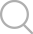

In [3]:
print(web.content)     # will give the entire html of the website

print(web.url)         # will print url of the website

print(web.status_code)      # will print the status of the website
# website it currently not allowing





<!DOCTYPE html>
<html data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en%22%7D%7D" data-n-head-ssr="" lang="en">
 <head>
  <meta charset="utf-8" data-n-head="ssr"/>
  <meta content="text/html" data-n-head="ssr" name="http-equiv"/>
  <meta content="width=device-width, initial-scale=1" data-n-head="ssr" name="viewport"/>
  <meta content="telephone=no" data-n-head="ssr" name="format-detection"/>
  <meta content="E_mHMxl8OOc7JXOce6JaGYnsHTczS2spGA35pac5-m0" data-hid="google-site-verification" data-n-head="ssr" name="google-site-verification"/>
  <meta content="768253706540902" data-hid="fb:app_id" data-n-head="ssr" name="fb:app_id"/>
  <meta content="website" data-hid="fb:type" data-n-head="ssr" name="fb:type"/>
  <meta content="Open Government Data (OGD) Platform India" data-hid="fb:site_name" data-n-head="ssr" name="fb:site_name"/>
  <meta content="https://data.gov.in" data-hid="fb:url" data-n-head="ssr" name="fb:url"/>
  <meta content="Open Government Data (OGD) Platform India" data-hid="fb:
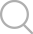

In [4]:
soup = BeautifulSoup(web.content, "html.parser")    # there are different types of parser, since we have html in web.content we will be entering "html.parser"

print(soup.prettify())          # this will print all the html of the website

---
---

In [5]:
import requests
from bs4 import BeautifulSoup      

In [6]:
# 1. Define headers to mimic a real web browser (like Chrome on Windows)
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}
# 2. Pass the headers into your request
url = "https://www.ambitionbox.com/list-of-companies?campaign=desktop_nav"

web = requests.get(url, headers=headers)

print(web)

<Response [200]>


b'<!doctype html>\n<html data-n-head-ssr lang="en" data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en%22%7D%7D">\n  <head >\n    <meta charset="UTF-8">\n    <meta name="viewport" content="width=device-width,initial-scale=1,minimum-scale=1">\n    <meta http-equiv="X-UA-Compatible" content="IE=edge"> \n    <link rel="manifest" href="/assets/next/manifest.json">\n    <style>@media only screen and (min-width:767px){.trp-img{width:400px!important;max-width:400px!important}}</style>\n    <script src="/static/js/env-runtime.js" defer></script>\n    <script>window.dataLayer=window.dataLayer||[],window.gtag=window.gtag||function(){window.dataLayer.push(arguments)},gtag("js",new Date),window.initialDate=(new Date).toISOString()</script>\n    <script>window.Prism=window.Prism||{},window.Prism.manual=!0</script>\n    <title>Top Companies in India | AmbitionBox</title><meta data-n-head="ssr" name="copyright" content="2026 AmbitionBox"><meta data-n-head="ssr" name="revisit-after" content="1 day"><meta da
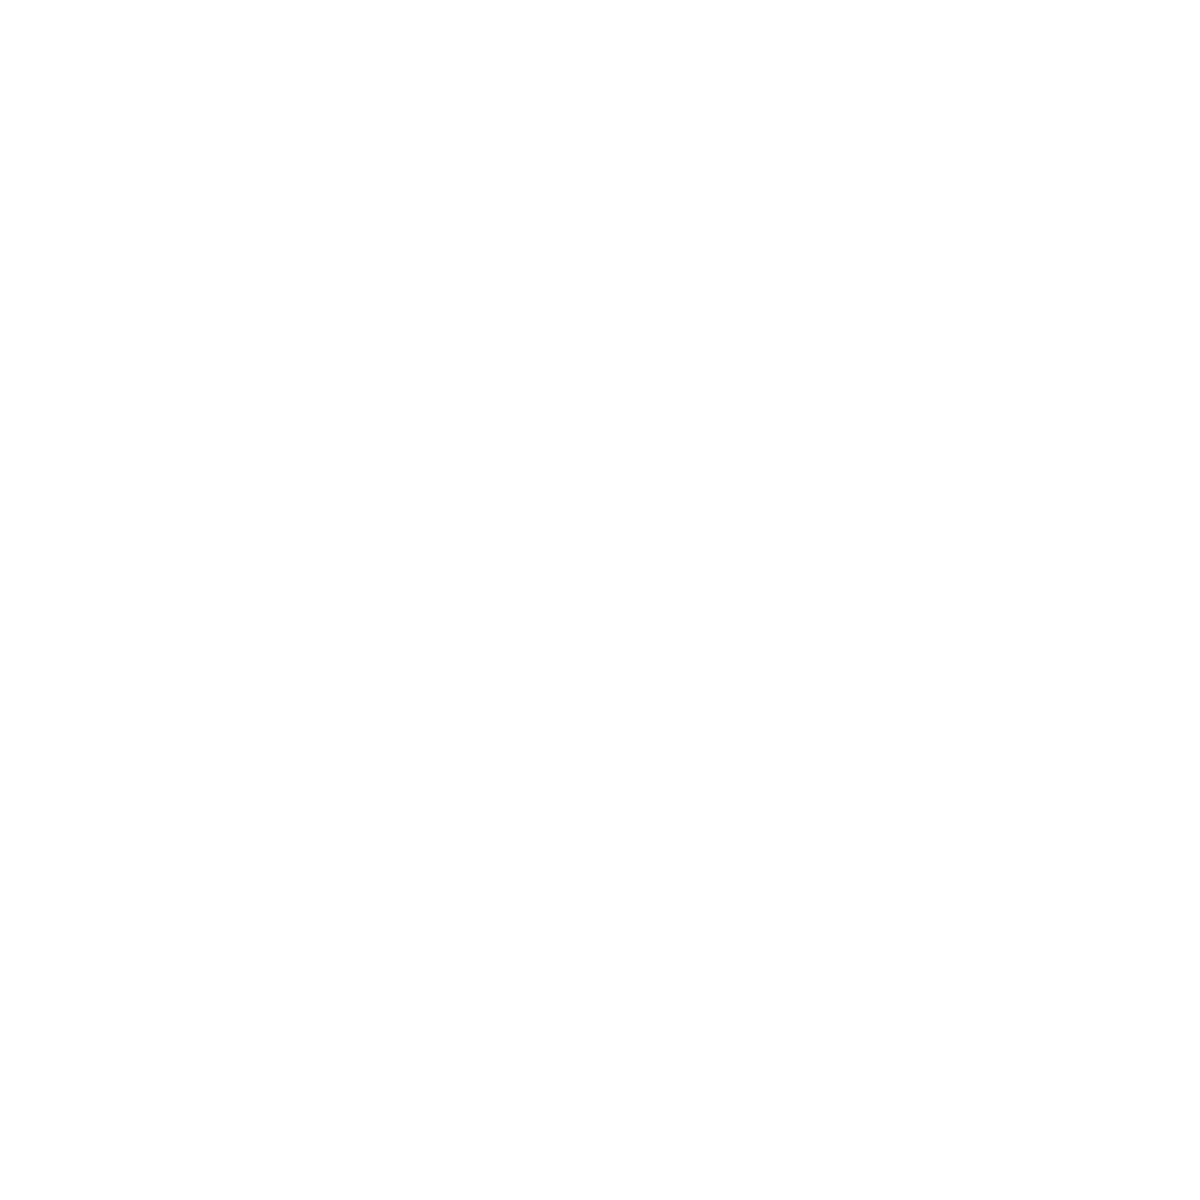

In [7]:
print(web.content)     # will give the entire html of the website

print(web.url)         # will print url of the website

print(web.status_code)      # will print the status of the website
# website it currently not allowing





<!DOCTYPE html>
<html data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en%22%7D%7D" data-n-head-ssr="" lang="en">
 <head>
  <meta charset="utf-8"/>
  <meta content="width=device-width,initial-scale=1,minimum-scale=1" name="viewport"/>
  <meta content="IE=edge" http-equiv="X-UA-Compatible"/>
  <link href="/assets/next/manifest.json" rel="manifest"/>
  <style>
   @media only screen and (min-width:767px){.trp-img{width:400px!important;max-width:400px!important}}
  </style>
  <script defer="" src="/static/js/env-runtime.js">
  </script>
  <script>
   window.dataLayer=window.dataLayer||[],window.gtag=window.gtag||function(){window.dataLayer.push(arguments)},gtag("js",new Date),window.initialDate=(new Date).toISOString()
  </script>
  <script>
   window.Prism=window.Prism||{},window.Prism.manual=!0
  </script>
  <title>
   Top Companies in India | AmbitionBox
  </title>
  <meta content="2026 AmbitionBox" data-n-head="ssr" name="copyright"/>
  <meta content="1 day" data-n-head="ssr" name="revisit-a
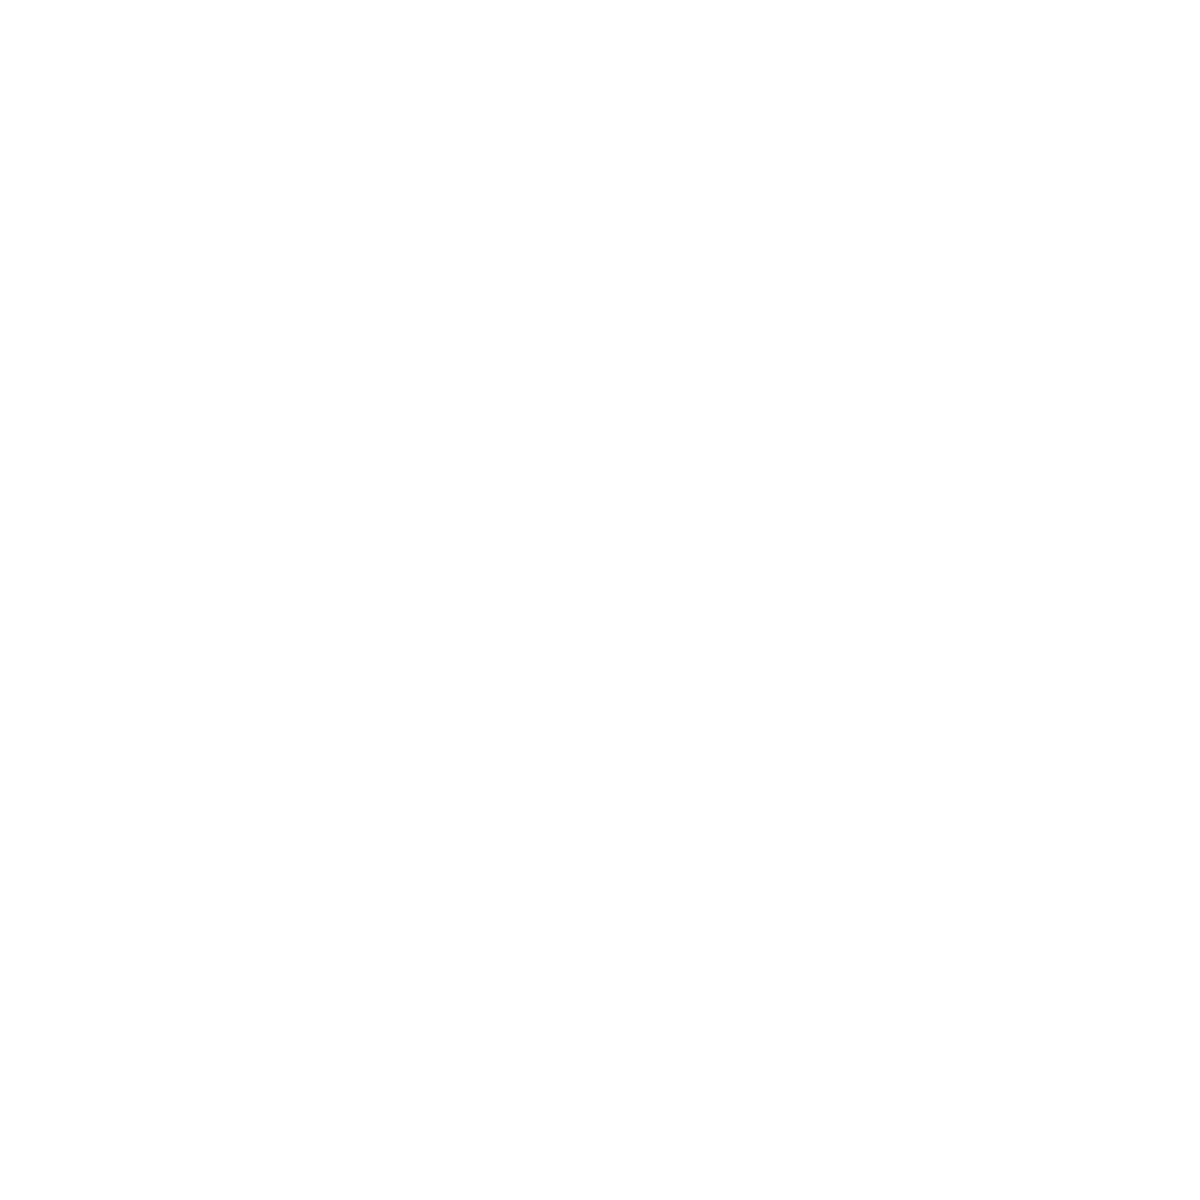

In [8]:
soup = BeautifulSoup(web.content, "html.parser")    

print(soup.prettify())        

In [16]:
print(soup.title, '\n')           # will print the title of the code
print(soup.title.name, '\n')        # prints the tag name of title

<title>Top Companies in India | AmbitionBox</title> 

title 



In [17]:
print(soup.p)        # prints first paragraph tag

<p class="text" style="color:#040a1e;">
						AmbitionBox
					</p>


In [18]:
soup.a          # prints first anchor tag

<a class="logo" href="/"><img alt="AmbitionBox" height="32" src="https://static.ambitionbox.com/static/logo.svg" style="filter:unset;" width="26.5"/> <p class="text" style="color:#040a1e;">
						AmbitionBox
					</p></a>

In [24]:
soup.h1

<h1 class="companyListing__collectionTopHeadingCont" data-v-507d085f=""><div class="companyListing__collectionTopHeading" data-v-507d085f="">
					Top Companies in
				</div> <div class="companyListing__collectionIndiaHeading" data-v-507d085f=""><img data-v-507d085f="" height="12" src="https://static.ambitionbox.com/static/loc/loc-star.png" width="12"/>
					INDIA
					<img data-v-507d085f="" height="12" src="https://static.ambitionbox.com/static/loc/loc-star.png" width="12"/></div></h1>

**Lets make an object for the url**

In [32]:
obj = soup.html
type(obj)           # the will be of the type 'tag'

bs4.element.Tag

In [61]:
print(obj.title)
print(obj.title.string, '\n')     # prints the string inside of any element

print(obj.p.string)             # prints the strings with the tabs and spaces used on them
print(obj.p.string.strip())     # removes the unnecessary tabs and spaces

<title>Top Companies in India | AmbitionBox</title>
Top Companies in India | AmbitionBox 


						AmbitionBox
					
AmbitionBox


In [62]:
print(obj.find('h2'), '\n')     # prints the first h2 tag

print(obj.find_all('h2'))       # prints all the h2 tags

<h2 class="companyListing__title">
								Companies in India
							</h2> 

[<h2 class="companyListing__title">
								Companies in India
							</h2>, <h2 class="companyCardWrapper__companyName" title="TCS">
										TCS
									</h2>, <h2 class="companyCardWrapper__companyName" title="Accenture">
										Accenture
									</h2>, <h2 class="companyCardWrapper__companyName" title="Wipro">
										Wipro
									</h2>, <h2 class="companyCardWrapper__companyName" title="Cognizant">
										Cognizant
									</h2>, <h2 class="companyCardWrapper__companyName" title="Capgemini">
										Capgemini
									</h2>, <h2 class="companyCardWrapper__companyName" title="HDFC Bank">
										HDFC Bank
									</h2>, <h2 class="companyCardWrapper__companyName" title="Infosys">
										Infosys
									</h2>, <h2 class="companyCardWrapper__companyName" title="ICICI Bank">
										ICICI Bank
									</h2>, <h2 class="companyCardWrapper__companyName" title="HCLTech">
										HCLTe

<body>

<div data-server-rendered="true" id="__nuxt"><div id="__layout"><div class="tabsLayout"><div class="tabsLayout__header"><header class="ab_header animted mobile whiteDesktop" id="ambitionbox-header"><div class="navbar"><div class="left-container"><!-- --> <a class="logo" href="/"><img alt="AmbitionBox" height="32" src="https://static.ambitionbox.com/static/logo.svg" style="filter:unset;" width="26.5"/> <p class="text" style="color:#040a1e;">
						AmbitionBox
					</p></a> <a class="g-flex-v-center open-menu visible-xs p-6"></a> <div class="nav-list-left"><div class="ab_typeahead4 container container" style="background-image:url('https://static.ambitionbox.com/static/icons/typeahead/companies.svg');background-position:96% 161%;background-size:200px;"><!-- --> <!-- --> <div class="typeahead-wrapper3"><div class="wrapper-wthout-btn"><div class="search-company component-search-company search-company-wth-btn"><img class="search-icon" height="16" src="https://static.ambitionbox.com/s
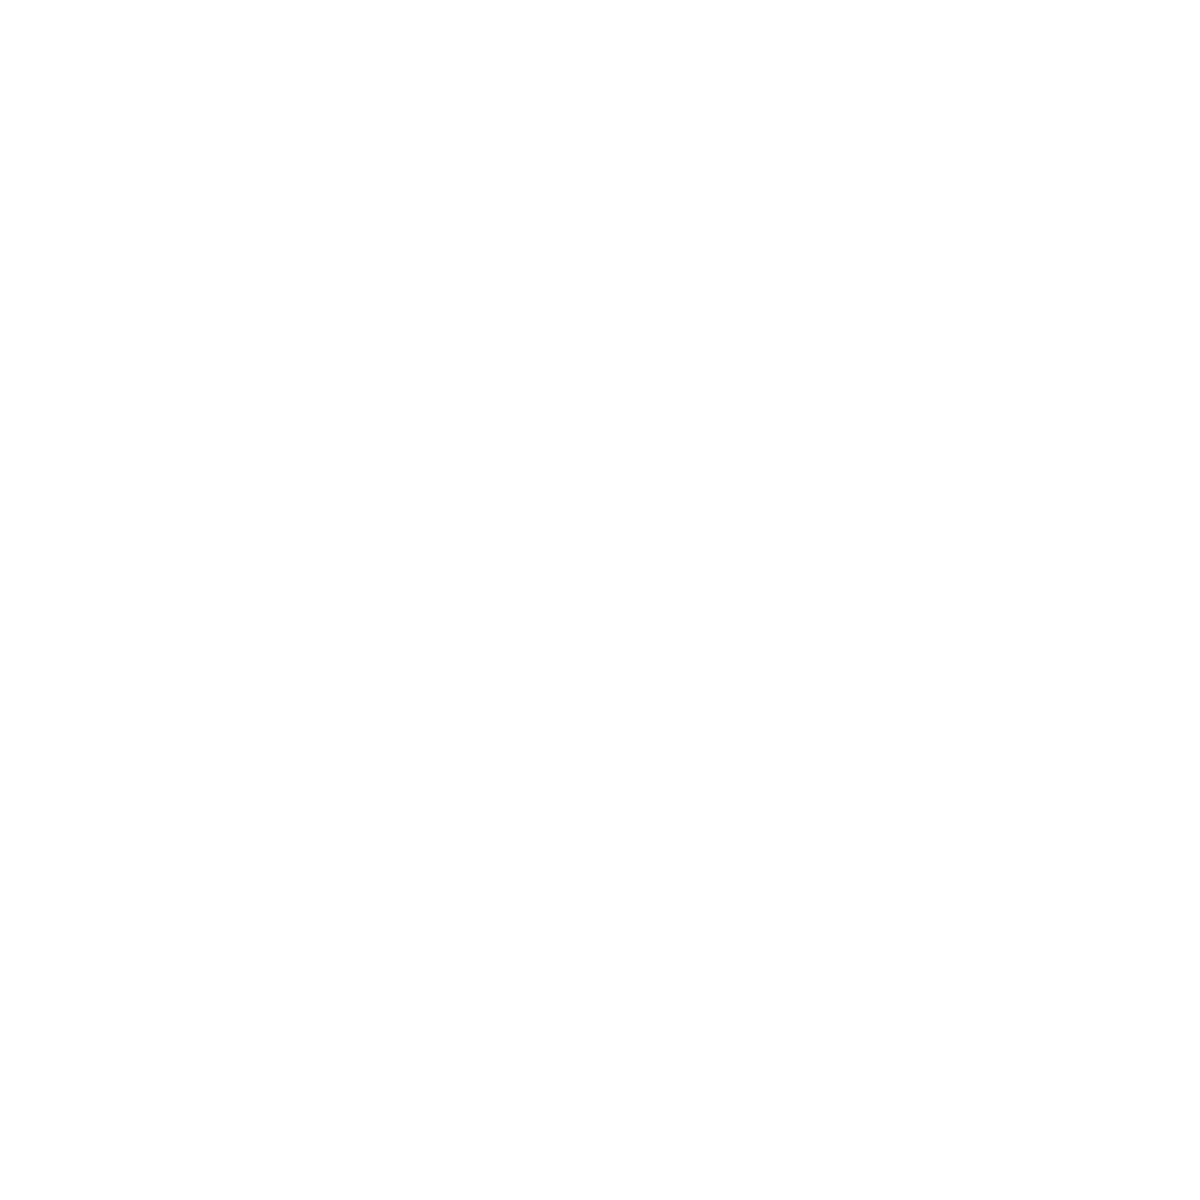

In [ ]:
print(obj.body)

<body>
 
 <div data-server-rendered="true" id="__nuxt">
  <div id="__layout">
   <div class="tabsLayout">
    <div class="tabsLayout__header">
     <header class="ab_header animted mobile whiteDesktop" id="ambitionbox-header">
      <div class="navbar">
       <div class="left-container">
        <!-- -->
        <a class="logo" href="/">
         <img alt="AmbitionBox" height="32" src="https://static.ambitionbox.com/static/logo.svg" style="filter:unset;" width="26.5"/>
         <p class="text" style="color:#040a1e;">
          AmbitionBox
         </p>
        </a>
        <a class="g-flex-v-center open-menu visible-xs p-6">
         
        </a>
        <div class="nav-list-left">
         <div class="ab_typeahead4 container container" style="background-image:url('https://static.ambitionbox.com/static/icons/typeahead/companies.svg');background-position:96% 161%;background-size:200px;">
          <!-- -->
          <!-- -->
          <div class="typeahead-wrapper3">
           <div c
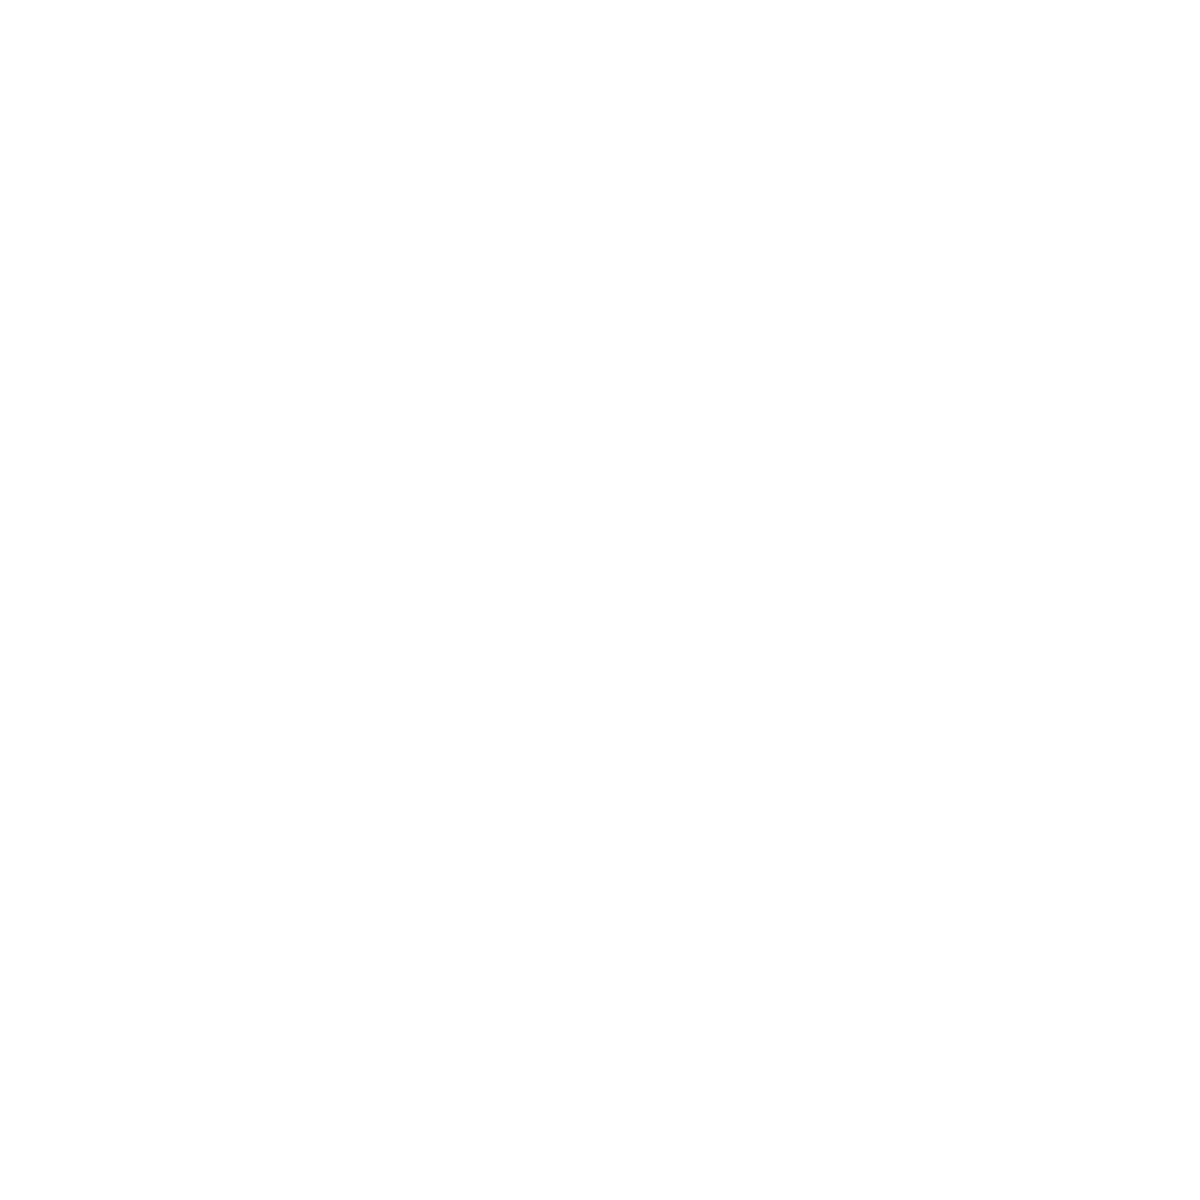

In [71]:
print(obj.body.prettify())      # prints everything in a html readable format

In [81]:
obj.find("div", class_="companyCardWrapper")

<div class="companyCardWrapper" itemprop="itemListElement" itemscope="itemscope" itemtype="http://schema.org/ListItem"><meta content="1" itemprop="position"/> <meta content="TCS" itemprop="name"/> <meta content="Tata Consultancy Services" itemprop="alternateName"/> <meta content="https://www.ambitionbox.com/overview/tcs-overview" itemprop="url"/> <meta content="https://static.ambitionbox.com/alpha/company/photos/logos/tcs.jpg" itemprop="image"/> <div class="companyCardWrapper__primaryInformation"><div class="companyCardWrapper__companyLogo"><img alt="Tata Consultancy Services logo" height="50" loading="lazy" onerror="this.onerror=null;this.src='/static/icons/company-placeholder.svg';" src="https://static.ambitionbox.com/assets/v2/images/rs:fit:200:200:false:false/aHR0cHM6Ly9tZWRpYS5uYXVrcmkuY29tL21lZGlhL2FiY29tcGxvZ28vdGNzLW9yaWdpbmFsLmpwZw.webp" width="50"/></div> <div class="companyCardWrapper__metaInformation"><div class="companyCardWrapper__header"><div class="companyCardWrapper__c

In [131]:
head = obj.find_all("h2", class_="companyCardWrapper__companyName")

head = [i.string.strip() for i in head]
head

['TCS',
 'Accenture',
 'Wipro',
 'Cognizant',
 'Capgemini',
 'HDFC Bank',
 'Infosys',
 'ICICI Bank',
 'HCLTech',
 'Tech Mahindra',
 'Genpact',
 'TP',
 'Jio',
 'Axis Bank',
 'Concentrix Corporation',
 'Amazon',
 'Reliance Retail',
 'iEnergizer',
 'LTIMindtree',
 'IBM']